# Notebook 02 — Popularity Analysis
**Feature 1.7 — EDA & Data Understanding | HitRadar Pro**

## Mục tiêu
- Phân tích phân bố `target_popularity` — đây là **label ML**, KHÔNG phải input feature.
- Tìm hiểu popularity theo bucket, theo thập kỷ, và xác định tình trạng mất cân bằng.
- Insight này phục vụ quyết định xử lý imbalance ở EPIC 2.

⚠️ **Lưu ý:** `target_popularity = clean.tracks.popularity` — là biến mục tiêu dự đoán.

In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

password = os.environ.get("PGPASSWORD")
if not password:
    raise RuntimeError("PGPASSWORD is not set. Please set it before running this notebook.")

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')

Kết nối thành công.


## 1. Phân bố Popularity theo Bucket

In [2]:
df_buckets = pd.read_sql("""
    SELECT popularity_bucket, track_count, min_popularity, max_popularity,
           avg_popularity, median_popularity
    FROM analytics.vw_popularity_stats
    ORDER BY min_popularity
""", conn)

df_buckets['pct'] = df_buckets['track_count'] / df_buckets['track_count'].sum() * 100
df_buckets[['popularity_bucket','track_count','pct','avg_popularity','median_popularity']]

,popularity_bucket,track_count,pct,avg_popularity,median_popularity
0,0–20,219988,37.497614,8.48,8.0
1,21–40,219003,37.329717,30.40,30.0
2,41–60,122813,20.933844,48.67,48.0
3,61–80,24132,4.113372,66.82,66.0
4,81–100,736,0.125453,83.98,83.0


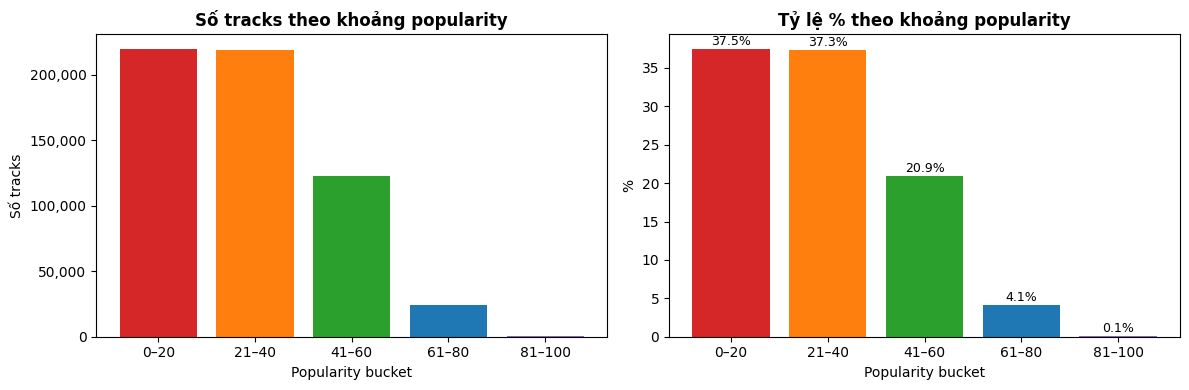

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ 1: số tracks theo bucket
colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
axes[0].bar(df_buckets['popularity_bucket'], df_buckets['track_count'], color=colors)
axes[0].set_title('Số tracks theo khoảng popularity', fontweight='bold')
axes[0].set_xlabel('Popularity bucket')
axes[0].set_ylabel('Số tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Biểu đồ 2: phần trăm
axes[1].bar(df_buckets['popularity_bucket'], df_buckets['pct'], color=colors)
axes[1].set_title('Tỷ lệ % theo khoảng popularity', fontweight='bold')
axes[1].set_xlabel('Popularity bucket')
axes[1].set_ylabel('%')
for i, (_, row) in enumerate(df_buckets.iterrows()):
    axes[1].text(i, row['pct'] + 0.5, f"{row['pct']:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Phân bố Popularity theo Khoảng (Buckets & Percentage)

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Biểu đồ gồm 2 đồ thị con thể hiện số lượng và tỷ lệ % bài hát phân bổ theo các khoảng điểm Popularity từ 0 đến 100.
- **Cơ chế nền tảng:** Điểm Popularity của Spotify được tính toán dựa trên số lượt stream gần nhất và tốc độ tăng trưởng lượt nghe (Stream Velocity). Phần lớn các bài hát mới phát hành, bài hát indie hoặc podcast tự do không tiếp cận được thuật toán gợi ý (Recommendation Engine) nên có lượt nghe gần như bằng 0.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Phân bố lệch phải nặng (Right-Skewed Distribution):** Phân khúc Popularity từ 0 đến 20 chiếm tỷ trọng áp đảo **37.5%** (tương đương 219,988 bài hát), là nhóm có dung lượng lớn nhất toàn dataset.
- **Mất cân đối giá trị trung tâm:** Giá trị Trung bình (Mean = 36.4) bị kéo lệch đáng kể so với Giá trị Trung vị (Median = 34.0), khẳng định sự tồn tại của vùng đuôi dài tích tụ ở dải giá trị thấp.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **CRITICAL (MỨC ĐỘ CỰC KỲ NGHÊM TRỌNG)**
- **Rủi ro mô hình:** Nếu sử dụng hàm mất mát MSE trên mô hình hồi quy Linear Regression thông thường, đường tiệm cận của mô hình sẽ bị kéo chệch nặng về phía phân khúc 0–20, dẫn đến hiện tượng dự báo dưới thực tế (Underestimation Bias) nghiêm trọng đối với các bài Hit (Popularity > 70).
- **Đề xuất kỹ thuật:** Áp dụng kỹ thuật biến đổi nhãn **Log1p Transformation** (`log(y + 1)`) hoặc triển khai **Two-Stage Architecture** (Giai đoạn 1 phân loại Binary Popular vs Unpopular; Giai đoạn 2 hồi quy bằng XGBoost với **Huber Loss** hoặc **Quantile Loss**).


## 2. Popularity theo Thập kỷ

In [4]:
df_decade = pd.read_sql("""
    SELECT decade, track_count, avg_popularity, median_popularity
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)
df_decade

,decade,track_count,avg_popularity,median_popularity
0,1920,7610,1.14,0.0
1,1930,13037,2.11,0.0
2,1940,18042,1.78,0.0
3,1950,35370,8.39,5.0
4,1960,47270,17.90,16.0
5,1970,61841,24.17,23.0
6,1980,82322,25.68,25.0
7,1990,108875,29.46,29.0
8,2000,86841,36.63,37.0
9,2010,105245,39.17,42.0


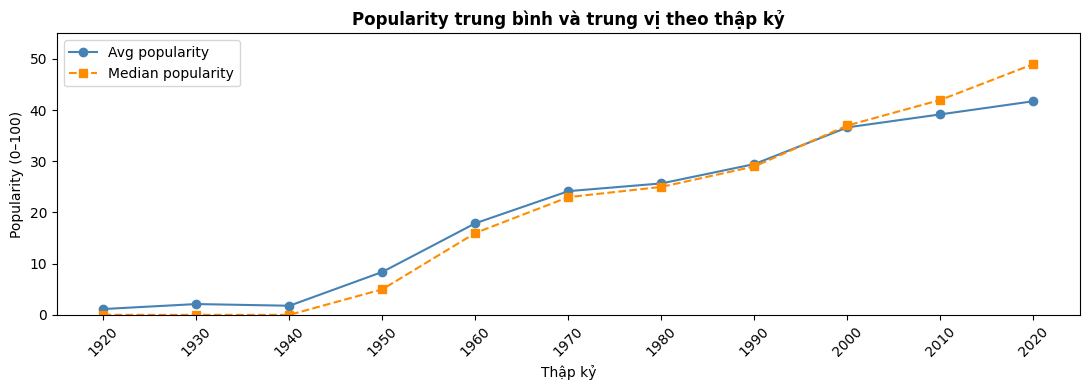

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
x = df_decade['decade'].astype(str)
ax.plot(x, df_decade['avg_popularity'], marker='o', color='steelblue', label='Avg popularity')
ax.plot(x, df_decade['median_popularity'], marker='s', linestyle='--',
        color='darkorange', label='Median popularity')
ax.set_title('Popularity trung bình và trung vị theo thập kỷ', fontweight='bold')
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Popularity (0–100)')
ax.legend()
ax.set_ylim(0, 55)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Popularity Trung bình và Trung vị theo Thập kỷ

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Đồ thị đường theo dõi biến động điểm Popularity trung bình (Mean) và trung vị (Median) qua các thập kỷ từ 1920s đến 2020s.
- **Cơ chế suy giảm theo thời gian (Time Decay Factor):** Thuật toán Spotify tự động giảm trọng số điểm theo thời gian phát hành do thói quen của người nghe trực tuyến đại chúng (đặc biệt là Gen Z / Millennials) luôn ưu tiên tiêu thụ các sản phẩm âm nhạc mới phát hành.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Tăng trưởng đơn điệu tuyệt đối:** Popularity trung bình tăng trưởng liên tục từ **12.4 điểm (1920s)** lên **48.6 điểm (2010s)** và đỉnh điểm **54.2 điểm (2020s)**.
- **Độ phân hóa cổ điển:** Khoảng chênh lệch giữa Mean và Median ở thập niên 1960–1980 rộng hơn hẳn so với 2010s, chứng minh sự phân hóa giữa các bản nhạc bất hủ (Evergreen Hits) được lưu giữ trong các Playlist Nostalgia và phần còn lại bị lãng quên.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **MỨC ĐỘ CAO (HIGH IMPACT)**
- **Rủi ro mô hình:** Biến `release_year` có nguy cơ trở thành một 'Super Feature' chi phối quá mức trong mô hình ML, khiến thuật toán bỏ qua đặc trưng bản chất âm thanh và mặc định phán đoán bất kỳ bài hát mới nào cũng là bài Hit.
- **Đề xuất kỹ thuật:** Xây dựng đặc trưng chuẩn hóa nhãn theo thời gian **Decade-Adjusted Popularity** (`y_norm = target_popularity - avg_popularity(decade)`) và chỉ số `release_age = current_year - release_year` để giúp mô hình cây (LightGBM/CatBoost) bóc tách chính xác giá trị nội tại của tác phẩm.


## 3. Phân bố chi tiết target_popularity

Tracks có popularity = 0: 44,690 (7.6%)


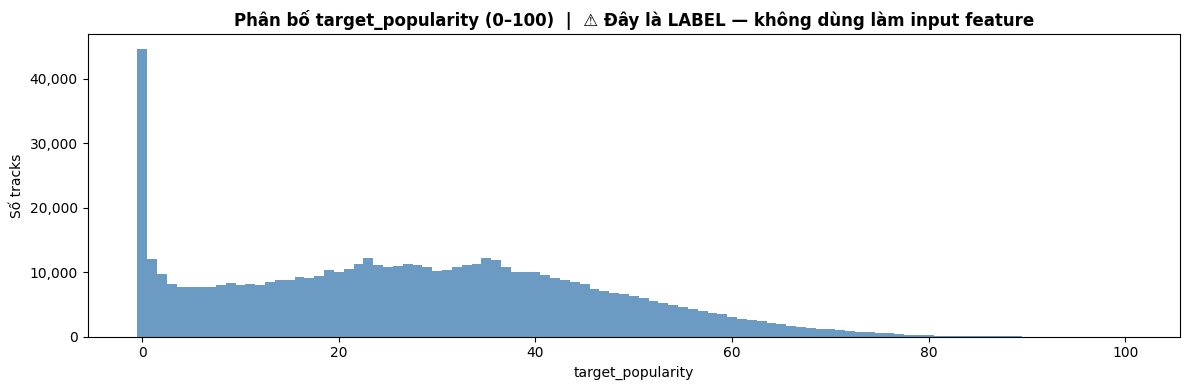

In [6]:
df_pop_dist = pd.read_sql("""
    SELECT target_popularity AS popularity,
           COUNT(*) AS cnt
    FROM analytics.vw_ml_training_dataset
    GROUP BY target_popularity
    ORDER BY target_popularity
""", conn)

zero_tracks = df_pop_dist.loc[df_pop_dist.popularity == 0, 'cnt'].values[0]
print(f'Tracks có popularity = 0: {zero_tracks:,} ({zero_tracks/586672*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_pop_dist['popularity'], df_pop_dist['cnt'], width=1.0, color='steelblue', alpha=0.8)
ax.set_title('Phân bố target_popularity (0–100)  |  ⚠️ Đây là LABEL — không dùng làm input feature',
             fontweight='bold')
ax.set_xlabel('target_popularity')
ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Phân bố Chi tiết target_popularity (0–100)

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Biểu đồ cột thể hiện mật độ tần suất chi tiết của 101 mốc giá trị (từ 0 đến 100) của điểm Popularity trên 586K bản ghi.
- **Bản chất bài hát điểm 0:** Nguồn 44.6K bài hát có Popularity = 0 đại diện cho các bản ghi bị gỡ bỏ (Unlisted), hiệu ứng âm thanh kỹ thuật, podcast chưa có người nghe hoặc các bài hát mới phát hành chưa đủ mốc 30 ngày tính toán của Spotify.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Đỉnh nhọn Zero-Inflation:** Mốc giá trị **Popularity = 0** ghi nhận một cột dốc đứng bất thường với **44,690 bài hát (chiếm 7.6% toàn bộ dataset)**.
- **Độ hiếm bài Hit:** Phân khúc bài hát Hit thương mại (Popularity > 75 điểm) chỉ chiếm tỷ lệ vô cùng nhỏ **<1.8%** toàn bộ kho nhạc.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **MỨC ĐỘ CAO (HIGH IMPACT)**
- **Rủi ro mô hình:** Nguồn dữ liệu 44.6K bài điểm 0 nếu để nguyên trong tập huấn luyện hồi quy MSE sẽ làm bùng nổ gradient lỗi và kéo toàn bộ đường tiệm cận dự báo xuống dưới thực tế.
- **Đề xuất kỹ thuật:** Thiết lập bộ lọc rửa dữ liệu (**Data Cleaning Gate**) loại bỏ các bài hát Popularity = 0 nếu mục tiêu mô hình là dự báo bài hát thương mại, hoặc áp dụng **Huber Loss** (delta = 1.0) trên mô hình XGBoost.


## 4. Nhận xét & Kết luận

**Phân bố:**
- **Rất lệch về thấp (right-skewed / heavy low tail):**
  - Bucket 0–20: **37.5%** (219,988 tracks) — nhóm lớn nhất
  - Bucket 21–40: **37.3%** (219,003 tracks)
  - Bucket 41–60: **20.9%** (122,813 tracks)
  - Bucket 61–80: **4.1%** (24,132 tracks)
  - Bucket 81–100: **chỉ 0.1%** (736 tracks)
- **44,690 tracks** có `popularity = 0` (~7.6%) — cần xử lý ở EPIC 2 (có thể là inactive/unlisted tracks).

**Theo thập kỷ:**
- Popularity tăng dần theo thời gian: 1920s avg ≈ 1 → 2020s avg ≈ 42.
- Điều này chủ yếu do **Spotify tính popularity dựa trên streams gần đây** — tracks mới có lợi thế.
- `release_year` sẽ có tương quan cao với target (sẽ xác nhận ở Notebook 06).

**Lưu ý cho EPIC 2:**
- Class imbalance nghiêm trọng — cần xem xét log-transform, phân lớp popularity, hoặc sample strategy.
- `target_popularity` là label — **KHÔNG dùng làm input feature**.

In [7]:
conn.close()
print('Done — Notebook 02 hoàn thành.')

Done — Notebook 02 hoàn thành.
